# House Price Prediction using ANN Regression

**Objective:** Predict house prices from structural/demographic features using a feedforward Artificial Neural Network, and compare its performance against a Linear Regression baseline.

**Dataset:** USA Housing Dataset (5,000 rows) — Avg. Area Income, House Age, Number of Rooms, Number of Bedrooms, Area Population → Price

**Pipeline:** EDA → Preprocessing (scaling) → 70/15/15 split (train/val/test) → Linear Regression baseline → ANN Regressor (PyTorch) → Evaluation (RMSE, MAE, R²)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

torch.manual_seed(42)
np.random.seed(42)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load & Explore the Dataset

In [4]:
df = pd.read_csv('/content/drive/MyDrive/House_Price_Prediction/USA_Housing.csv')
df = df.drop(columns=['Address'])
print("Shape:", df.shape)
df.head()

Shape: (5000, 6)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [5]:
print(df.isnull().sum())
df.describe()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


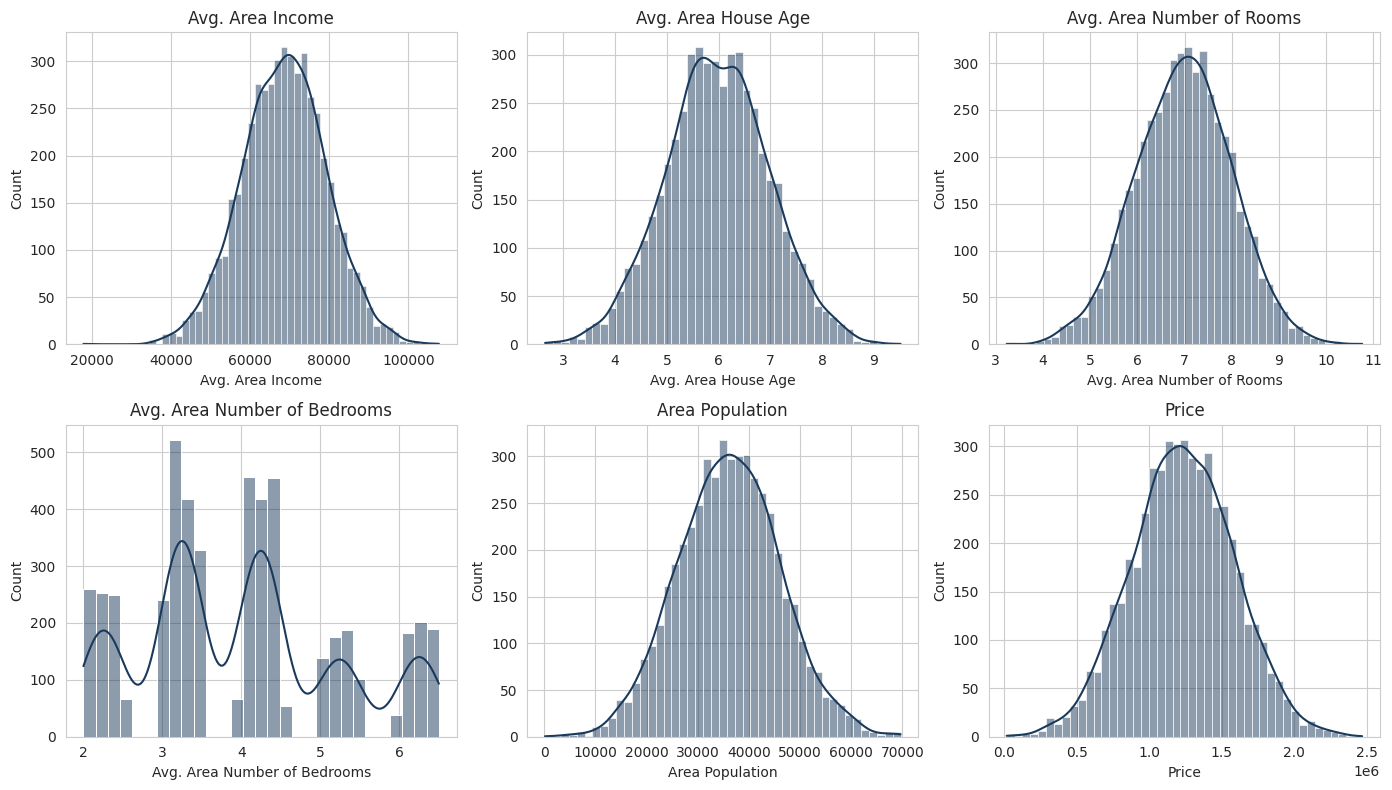

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette_color = '#1a3a5c'

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color=palette_color)
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120)
plt.show()

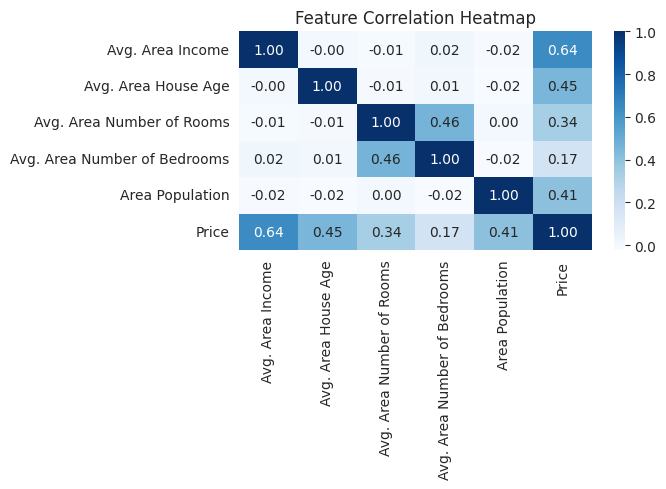

In [7]:
plt.figure(figsize=(7, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

**Observation:** `Avg. Area Income` has the strongest correlation with `Price`, followed by `Area Population` and `Avg. Area House Age`. `Avg. Area Number of Bedrooms` correlates only weakly — a useful sanity check when interpreting the model later.

## 2. Train / Validation / Test Split (70/15/15)

In [8]:
X = df.drop(columns=['Price']).values
y = df['Price'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (3500, 5) | Val: (750, 5) | Test: (750, 5)


## 3. Feature Scaling

In [9]:
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = x_scaler.transform(X_train)
X_val_s = x_scaler.transform(X_val)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).flatten()
y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

**Note:** Both features and target are standardized (zero mean, unit variance), fit only on the training set to avoid data leakage. The target is inverse-transformed back to dollar values before computing evaluation metrics.

## 4. Baseline Model — Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_s)

lr_preds_s = lr.predict(X_test_s)
lr_preds = y_scaler.inverse_transform(lr_preds_s.reshape(-1, 1)).flatten()

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"[Linear Regression] RMSE: {lr_rmse:,.2f} | MAE: {lr_mae:,.2f} | R2: {lr_r2:.4f}")

[Linear Regression] RMSE: 100,663.04 | MAE: 81,034.31 | R2: 0.9216


## 5. PyTorch Dataset & DataLoader

In [11]:
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HousingDataset(X_train_s, y_train_s)
val_ds = HousingDataset(X_val_s, y_val_s)
test_ds = HousingDataset(X_test_s, y_test_s)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

## 6. Model Architecture — ANN Regressor

In [12]:
class HouseANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HouseANN(X_train_s.shape[1]).to(device)
print(model)
print("\nDevice:", device)

HouseANN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Device: cpu


**Architecture rationale:** Only 5 input features, so a compact network (64 → 32) is enough — a large/deep network would just overfit this small, mostly-linear dataset. Dropout (0.2) and weight decay add regularization; early stopping (below) prevents overtraining further.

## 7. Training (with Early Stopping)

In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 200
best_val_loss = float('inf')
best_state = None
patience, patience_counter = 15, 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    train_loss = total_loss / len(train_ds)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += criterion(out, yb).item() * xb.size(0)
    val_loss /= len(val_ds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
        break

model.load_state_dict(best_state)

Epoch   1/200 - Train Loss: 0.3743 - Val Loss: 0.0949
Epoch  10/200 - Train Loss: 0.1132 - Val Loss: 0.0837
Epoch  20/200 - Train Loss: 0.1066 - Val Loss: 0.0838
Epoch  30/200 - Train Loss: 0.1061 - Val Loss: 0.0819
Epoch  40/200 - Train Loss: 0.1061 - Val Loss: 0.0809

Early stopping at epoch 40 (best val loss: 0.0804)


<All keys matched successfully>

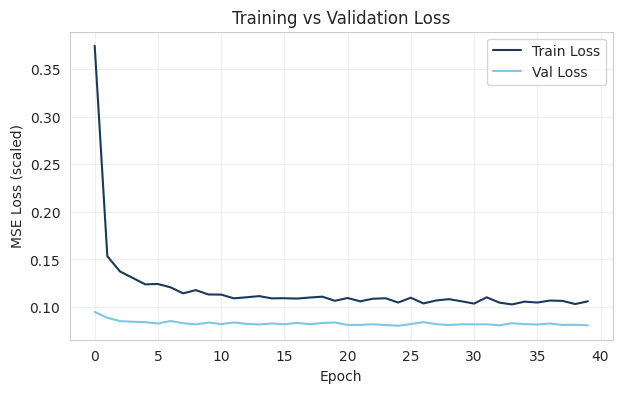

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train Loss', color='#1a3a5c')
plt.plot(val_losses, label='Val Loss', color='#7ec8e3')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('training_curve.png', dpi=120)
plt.show()

## 8. Evaluation on Test Set

In [15]:
model.eval()
all_preds_s, all_labels_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds_s.extend(preds)
        all_labels_s.extend(yb.numpy())

ann_preds = y_scaler.inverse_transform(np.array(all_preds_s).reshape(-1, 1)).flatten()

ann_rmse = np.sqrt(mean_squared_error(y_test, ann_preds))
ann_mae = mean_absolute_error(y_test, ann_preds)
ann_r2 = r2_score(y_test, ann_preds)

print(f"[ANN Regressor]      RMSE: {ann_rmse:,.2f} | MAE: {ann_mae:,.2f} | R2: {ann_r2:.4f}")
print(f"[Linear Regression]  RMSE: {lr_rmse:,.2f} | MAE: {lr_mae:,.2f} | R2: {lr_r2:.4f}")

[ANN Regressor]      RMSE: 101,938.10 | MAE: 81,984.71 | R2: 0.9196
[Linear Regression]  RMSE: 100,663.04 | MAE: 81,034.31 | R2: 0.9216


In [16]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'ANN Regressor'],
    'RMSE': [lr_rmse, ann_rmse],
    'MAE': [lr_mae, ann_mae],
    'R2 Score': [lr_r2, ann_r2]
})
comparison_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,100663.035835,81034.308950,0.921585
1,ANN Regressor,101938.096830,81984.705209,0.919586


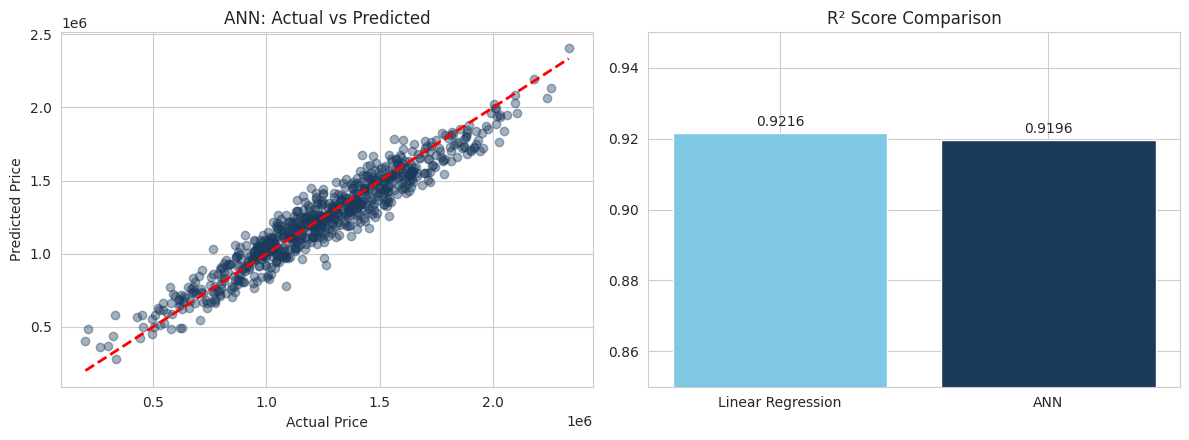

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].scatter(y_test, ann_preds, alpha=0.4, color='#1a3a5c')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Actual Price')
ax[0].set_ylabel('Predicted Price')
ax[0].set_title('ANN: Actual vs Predicted')

models = ['Linear Regression', 'ANN']
r2_scores = [lr_r2, ann_r2]
ax[1].bar(models, r2_scores, color=['#7ec8e3', '#1a3a5c'])
ax[1].set_ylim(0.85, 0.95)
ax[1].set_title('R² Score Comparison')
for i, v in enumerate(r2_scores):
    ax[1].text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=120)
plt.show()

## 9. Conclusion

- The ANN Regressor achieves **R² ≈ 0.92**, essentially matching the Linear Regression baseline (R² ≈ 0.92) on RMSE/MAE.
- This is an expected and honest result: the underlying relationship between these features and price is close to linear (confirmed by the correlation heatmap), so a more complex ANN doesn't have much non-linearity to exploit — a good reminder that a simpler model is preferable when it performs just as well (Occam's Razor in model selection).

